# Air quality on Vienna City Marathon dates

the data for this was sourced from https://researchdata.tuwien.ac.at/records/mtha8-w2406

To correctly illustrate the air quality during the marathon, sensors close to the course were choosen. This means that the sensors at the following locations were selected: Stefansplatz, Taborstraße, A23-Wehlistraße, Hietzinger Kai. For the sake of simplicity, and because the original data is quite large, only the final cleaned file (vienna_marathon_component_trends.csv) was added to git.

## Cleaning/accessing the data

Importing relevant libraries

In [7]:
import pandas as pd
import glob
import os
import numpy as np
import matplotlib.pyplot as plt

Access data from the relevant_data folder

In [32]:
data_dir = r"/relevant_data"

Define relevant marathon dates

In [33]:
marathon_dates = {
    2000: "2000-05-21", 2001: "2001-05-20", 2002: "2002-05-26",
    2003: "2003-05-25", 2004: "2004-05-16", 2005: "2005-05-22",
    2006: "2006-05-07", 2007: "2007-04-29", 2008: "2008-04-27",
    2009: "2009-04-19", 2010: "2010-04-18", 2011: "2011-04-17",
    2012: "2012-04-15", 2013: "2013-04-14", 2014: "2014-04-13",
    2015: "2015-04-12", 2016: "2016-04-10", 2017: "2017-04-23",
    2018: "2018-04-22", 2019: "2019-04-07",
    2021: "2021-09-12", 2022: "2022-04-24", 2023: "2023-04-23",
    2024: "2024-04-21", 2025: "2025-04-06", 2026: "2026-04-19"
}

Create list for targets to search for

In [34]:
target_patterns = []
for year, date_str in marathon_dates.items():
    dt = pd.to_datetime(date_str)
    suffix = f"HMW_{dt.strftime('%y.%m.%d')}"
    target_patterns.append((year, suffix, dt.date()))

all_filtered_data = []

print("Scanning local station folders for specific marathon days...")

Scanning local station folders for specific marathon days...


Find all station directories inside  data directory

In [35]:
if os.path.exists(data_dir):
    stations = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]

    for station in stations:
        for year, suffix, actual_date in target_patterns:
            # Construct the direct path to the file
            # Example: data_dir/A23_PM10G/2016/HMW_16.04.10
            target_file_path = os.path.join(data_dir, station, str(year), suffix)

            if os.path.exists(target_file_path):
                try:
                    # Read the space-separated data file
                    df = pd.read_csv(
                        target_file_path,
                        sep=r'\s+',
                        header=None,
                        low_memory=False
                    )

                    # Rename key columns cleanly
                    df = df.rename(columns={0: 'Time', 1: 'Value'})

                    # Add metadata columns
                    df['Date'] = actual_date
                    df['Station'] = station

                    # Keep only essential columns
                    df = df[['Date', 'Time', 'Station', 'Value']]
                    all_filtered_data.append(df)
                    print(f"-> Found and processed: {station} ({year})")

                except Exception as e:
                    print(f"Error reading file {target_file_path}: {e}")
else:
    print(f"Error: The directory path '{data_dir}' does not exist. Please check your path syntax.")

-> Found and processed: A23_CO (2014)
-> Found and processed: A23_CO (2015)
-> Found and processed: A23_CO (2016)
-> Found and processed: A23_CO (2017)
-> Found and processed: A23_CO (2018)
-> Found and processed: A23_CO (2019)
-> Found and processed: A23_CO (2021)
-> Found and processed: A23_NO (2014)
-> Found and processed: A23_NO (2015)
-> Found and processed: A23_NO (2016)
-> Found and processed: A23_NO (2017)
-> Found and processed: A23_NO (2018)
-> Found and processed: A23_NO (2019)
-> Found and processed: A23_NO (2021)
-> Found and processed: A23_NO2 (2014)
-> Found and processed: A23_NO2 (2015)
-> Found and processed: A23_NO2 (2016)
-> Found and processed: A23_NO2 (2017)
-> Found and processed: A23_NO2 (2018)
-> Found and processed: A23_NO2 (2019)
-> Found and processed: A23_NO2 (2021)
-> Found and processed: A23_PM10G (2014)
-> Found and processed: A23_PM10G (2015)
-> Found and processed: A23_PM10G (2016)
-> Found and processed: A23_PM10G (2017)
-> Found and processed: A23_PM1

Compile and save results to csv

In [36]:
if all_filtered_data:
    final_df = pd.concat(all_filtered_data, ignore_index=True)

    # Save it straight into your main project directory next to relevant_data
    output_path = os.path.join(os.path.dirname(data_dir), "vienna_marathon_air_quality_all_years.csv")
    final_df.to_csv(output_path, index=False)

    print(f"\n Success! Combined dataset saved to: {output_path}")
    print(f"Total rows gathered: {len(final_df)}")
else:
    print("\nNo matching files found. Check that your folder structure inside 'relevant_data' matches STATION/YEAR/HMW_date.")


 Success! Combined dataset saved to: C:\Users\aylin\DataspellProjects\Bigdata_eng_prj\vienna_marathon_air_quality_all_years.csv
Total rows gathered: 12624


## further cleaning/adjustment of the data

Now the relevant data was saved in a single file. However to work with this data, the data of a single day (regardless of time, to not falsify the data a time window in which most people complete the marathon (9:00-16:00) was chosen)

In [37]:
csv_path = r"/vienna_marathon_air_quality_all_years.csv"

df = pd.read_csv(csv_path)

In [38]:
df['Time'] = df['Time'].astype(str).str.zfill(4)
race_hours_df = df[(df['Time'] >= '0900') & (df['Time'] <= '1600')].copy()
race_hours_df['Year'] = pd.to_datetime(race_hours_df['Date']).dt.year

In [39]:
hourly_avg = race_hours_df.groupby(['Year', 'Station'])['Value'].mean().reset_index()

In [40]:
final_analysis_df = hourly_avg.pivot(index='Year', columns='Station', values='Value')
print(final_analysis_df.head())

Station  A23_CO  A23_NO  A23_NO2  A23_PM10G  A23_PM10S  A23_PM25G  A23_PM25S  \
Year                                                                           
2000        NaN     NaN      NaN        NaN        NaN        NaN        NaN   
2001        NaN     NaN      NaN        NaN        NaN        NaN        NaN   
2002        NaN     NaN      NaN        NaN        NaN        NaN        NaN   
2003        NaN     NaN      NaN        NaN        NaN        NaN        NaN   
2004        NaN     NaN      NaN        NaN        NaN        NaN        NaN   

Station  A23_SO2    MBA_CO     MBA_NO  ...   MBA_SO2     STEF_NO  STEF_NO2  \
Year                                   ...                                   
2000         NaN       NaN        NaN  ...       NaN -800.000000  1.850667   
2001         NaN  0.672741  40.310867  ...  1.771813    0.973699  4.850793   
2002         NaN  0.345723  20.941200  ...  0.657481    1.342915  3.109947   
2003         NaN  0.438297  28.379000  ...  1.158

In [41]:
final_analysis_df.to_csv("marathon_race_hours_pollution.csv")

To further simplify the data, all pollution measured (CO,NO,NO2,O3,PM10G,PM10S,PM25G,PM25S,SO2,TSP) regardless of location was combined into one value. Additionally, to avoid negative values (which occures with sensors sometimes when the air is exceptionally clean and of course doesn't mean that there is negative pollution) values were clipped so that the lowest possible value is 0.

In [42]:
clean_hours_csv = r"C:\Users\aylin\DataspellProjects\Bigdata_eng_prj\marathon_race_hours_pollution.csv"

In [43]:
if os.path.exists(clean_hours_csv):
    df = pd.read_csv(clean_hours_csv, index_col='Year')
    df = df.clip(lower=0.0)

    column_groups = {col: col.split('_')[-1] for col in df.columns}

    city_wide_trends = df.T.groupby(column_groups).mean().T

    dest_folder = r"C:\Users\aylin\DataspellProjects\Bigdata_eng_prj"
    output_file = os.path.join(dest_folder, "vienna_marathon_component_trends.csv")

    city_wide_trends.to_csv(output_file)
    print(f" Success! The simplified trends are saved at:\n--> {output_file}")

    # Show a quick preview of the results
    print("\nFile Preview (City-Wide Averages per Component):")
    print(city_wide_trends.head())
else:
    print(f"Error: Could not locate '{clean_hours_csv}'. Double-check the filename in your project folder.")

 Success! The simplified trends are saved at:
--> C:\Users\aylin\DataspellProjects\Bigdata_eng_prj\vienna_marathon_component_trends.csv

File Preview (City-Wide Averages per Component):
            CO         NO        NO2         O3  PM10G  PM10S  PM25G  PM25S  \
Year                                                                          
2000       NaN   0.000000   1.850667        NaN    NaN    NaN    NaN    NaN   
2001  0.672741  20.642283  19.855563  55.619800    NaN    NaN    NaN    NaN   
2002  0.345723  11.142057   9.317273  31.063733    NaN    NaN    NaN    NaN   
2003  0.438297  14.844646  15.020653  49.644600    NaN    NaN    NaN    NaN   
2004  0.198997   3.350593   2.535924  35.426867    NaN    NaN    NaN    NaN   

           SO2        TSP  
Year                       
2000  0.401333   0.000000  
2001  1.691980  20.131733  
2002  0.389102   4.215551  
2003  1.098151  19.231200  
2004  0.481998  19.436953  


Replace suspicious 0s with NAs and turn PMM10G/PM10s and PM25G/PM25S into just PM10 and PM25

In [6]:
df = pd.read_csv("vienna_marathon_component_trends.csv")

df["O3"] = df["O3"].replace(0.0, np.nan)

df["pm10"] = df[["PM10G", "PM10S"]].mean(axis=1)
df["pm25"] = df[["PM25G", "PM25S"]].mean(axis=1)

df = df.drop(columns=["PM10G", "PM10S", "PM25G", "PM25S", "TSP"])
print(df)
df.to_csv("vienna_marathon_component_trends.csv", index=False)

    Year        CO         NO        NO2         O3       SO2       pm10  \
0   2000       NaN   0.000000   1.850667        NaN  0.401333        NaN   
1   2001  0.672741  20.642283  19.855563  55.619800  1.691980        NaN   
2   2002  0.345723  11.142057   9.317273  31.063733  0.389102        NaN   
3   2003  0.438297  14.844646  15.020653  49.644600  1.098151        NaN   
4   2004  0.198997   3.350593   2.535924  35.426867  0.481998        NaN   
5   2005  0.541608   0.630510   1.843977  38.922800  0.000000  26.707000   
6   2006  0.438317  14.506525  16.641493        NaN  0.574538  36.712133   
7   2007  0.255175   7.105300   8.353827        NaN       NaN  26.775547   
8   2008  0.000000  13.490267  17.746533  57.977133  1.967627  25.968867   
9   2009  0.362151   0.652101   2.707613        NaN  0.981387  17.506160   
10  2010  0.327993   0.427031   2.543217  50.947067  0.000000  30.602367   
11  2011  0.000000   6.421205  14.634957  54.650400  2.592040  29.015633   
12  2012  0.

## Visualisation

In [14]:
aq = pd.read_csv("vienna_marathon_component_trends.csv")
weather = pd.read_csv("weather1.csv")

# clean
aq = aq.rename(columns={"Year": "year"})

# merge
df = weather.merge(aq, on="year", how="left")
print(df.columns.tolist())

['year', 'date', 'temp_c', 'feels_like', 'humidity', 'wind_kph', 'weather', 'clouds', 'rain_mm', 'CO', 'NO', 'NO2', 'O3', 'SO2', 'pm10', 'pm25']


The following plot shows the polutants in the air during marathon day. For some years certain polutants are missing-the values were deliberatedly left as NAs to not falsify anything but also to not lose data, since the time span is rather narrow.

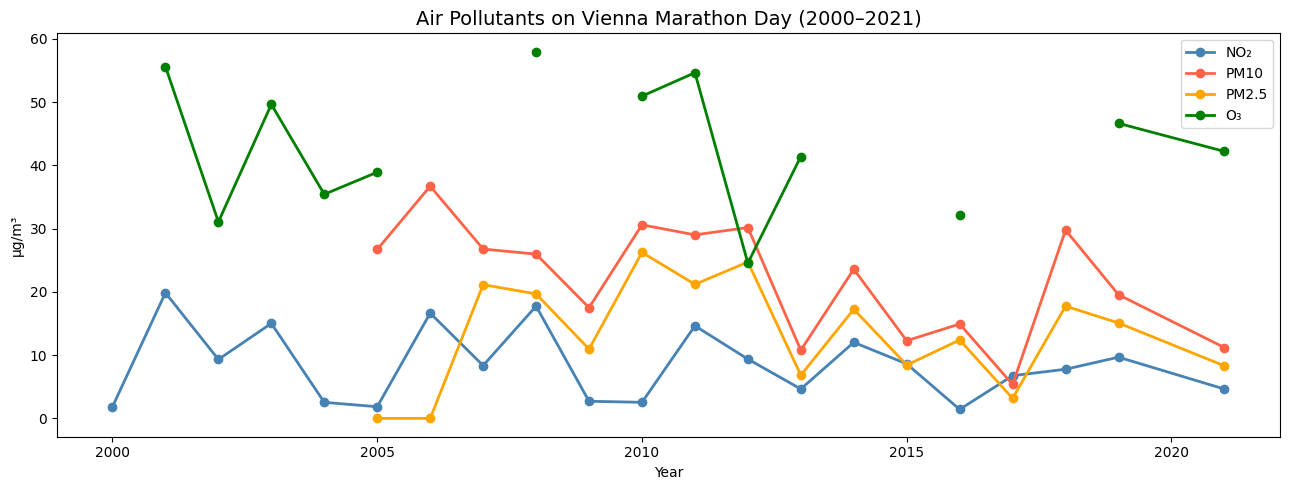

In [15]:
fig, ax = plt.subplots(figsize=(13, 5))
for col, color, label in [
    ("NO2",  "steelblue", "NO₂"),
    ("pm10", "tomato",    "PM10"),
    ("pm25", "orange",    "PM2.5"),
    ("O3",   "green",     "O₃"),
]:
    ax.plot(df["year"], df[col], marker="o", linewidth=2, label=label, color=color)
ax.set_title("Air Pollutants on Vienna Marathon Day (2000–2021)", fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("µg/m³")
ax.legend()
plt.tight_layout()
plt.savefig("aq_pollutant_trends.png", dpi=150)
plt.show()

The following plot shows the correlation between weather and air quality data points such as humidity or PM10 pollutants in the air.

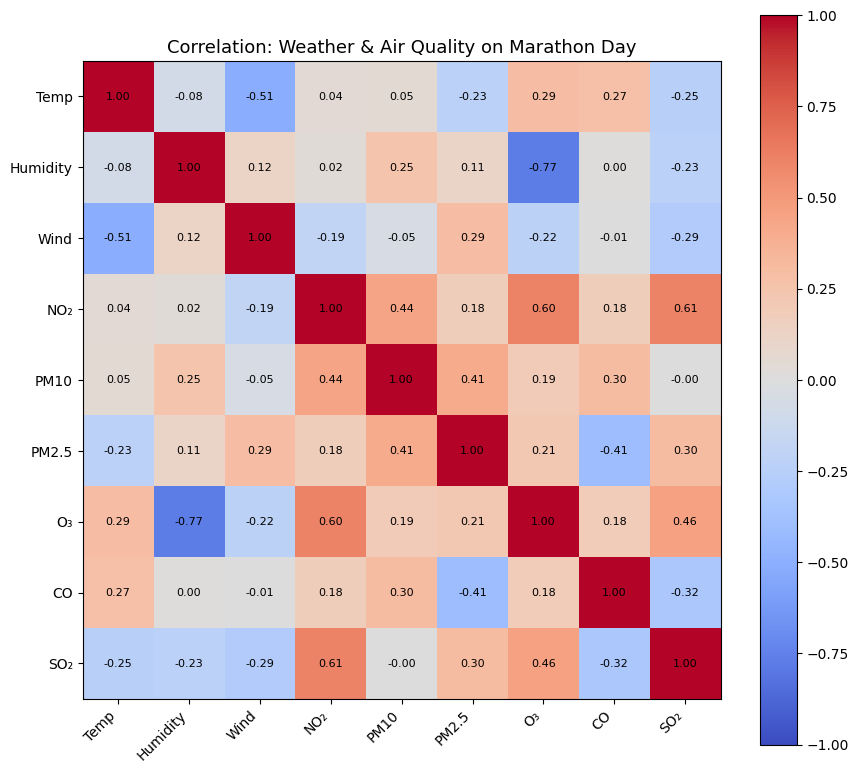

In [17]:
import matplotlib.colors as mcolors

corr_cols = ["temp_c", "humidity", "wind_kph", "NO2", "pm10", "pm25", "O3", "CO", "SO2"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
labels = ["Temp", "Humidity", "Wind", "NO₂", "PM10", "PM2.5", "O₃", "CO", "SO₂"]
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im)
ax.set_title("Correlation: Weather & Air Quality on Marathon Day", fontsize=13)
plt.tight_layout()
plt.savefig("aq_correlation.png", dpi=150)
plt.show()